<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/07_challenges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 — Analiza na challenges.csv (teški/granični primeri)

Evaluacija svih sačuvanih modela na 32 slike iz `challenges.csv` — ovo je **pravi held-out skup**:
te slike su namjerno isključene iz train/val/test podjele u `01_eda_split.ipynb`
(vidi `data_split.csv`, `split == 'excluded'`), tako da ih nijedan model nije vidio tokom treninga.

- **Cilj:** provjeriti kako se modeli ponašaju na slikama koje je autor dataset-a označio kao teške/granične
- **Ulaz:** sačuvani modeli (`models/`) + `challenges.csv` + `data_split.csv`
- **Test skup ovde:** 32 slike, potpuno odvojene od train/val/test

### 1. Priprema — slike, repo, sačuvani modeli

In [1]:
from google.colab import userdata
import os

# 1) slike sa Kaggle-a (sadrzi i challenges.csv unutar zip-a)
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
!pip install -U kaggle -q
!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
!unzip -q tom-and-jerry-image-classification.zip -d data/

# 2) repo - data_split.csv, features_hog_color.npy, sacuvani modeli u models/
token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "bibic.ilinka@gmail.com"
!git config user.name "Ika"

!ls models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.6 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:21<00:00, 21.2MB/s]

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 132 (delta 12), reused 1 (delta 1), pack-reused 112 (from 2)
Receiving objects: 100% (132/132), 236.98 MiB | 18.50 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (14/14), done.
/content/Tom-and-Jerry-Character-Classification
cnn_scratch.pt	      rf_final.joblib	svm_scaler.joblib
resnet18_transfer.pt  svm_final.joblib


### 2. Provjera — da li su challenge slike zaista van train/val/test

In [2]:
import pandas as pd

challenges = pd.read_csv('/content/data/challenges.csv')
split_df = pd.read_csv('data_split.csv')

print("challenges.csv:", challenges.shape)

merged = challenges.merge(split_df[['filename', 'split']], left_on='image_name', right_on='filename', how='left')

print("\nRaspodela po split-u:")
print(merged['split'].value_counts(dropna=False))

print("\nSvih 32 slike:")
print(merged[['folder', 'image_name', 'split']].to_string(index=False))

challenges.csv: (32, 2)

Raspodela po split-u:
split
excluded    32
Name: count, dtype: int64

Svih 32 slike:
folder    image_name    split
 jerry  frame360.jpg excluded
 jerry frame1794.jpg excluded
 jerry frame1795.jpg excluded
 jerry frame2231.jpg excluded
 jerry frame2234.jpg excluded
 jerry frame2941.jpg excluded
 jerry frame2942.jpg excluded
 jerry frame2943.jpg excluded
 jerry frame2944.jpg excluded
 jerry frame5399.jpg excluded
 jerry frame5400.jpg excluded
 jerry frame5401.jpg excluded
 jerry frame5408.jpg excluded
 jerry frame5436.jpg excluded
   tom   frame46.jpg excluded
   tom  frame715.jpg excluded
   tom frame1684.jpg excluded
   tom frame1685.jpg excluded
   tom frame1686.jpg excluded
   tom frame1768.jpg excluded
   tom frame2215.jpg excluded
   tom frame2154.jpg excluded
   tom frame2160.jpg excluded
   tom frame2946.jpg excluded
   tom frame2947.jpg excluded
   tom frame2948.jpg excluded
   tom frame2949.jpg excluded
   tom frame2950.jpg excluded
   tom frame2951.jpg

### 3. Priprema podataka za ovih 32 slike

In [3]:
import numpy as np

folder_map = {'tom': 'tom', 'jerry': 'jerry', 'both': 'tom_jerry_1', 'neither': 'tom_jerry_0'}
base_dir = '/content/data/tom_and_jerry/tom_and_jerry/'

# osobine (HOG+boje) za tih 32 slike - vec postoje u features_hog_color.npy, samo izvucemo pravi red
X_all = np.load('features_hog_color.npy')
challenge_mask = split_df['split'].values == 'excluded'
X_challenge = X_all[challenge_mask]

challenge_df = split_df[split_df['split'] == 'excluded'].reset_index(drop=True)
challenge_df['filepath'] = challenge_df.apply(lambda r: base_dir + folder_map[r['class']] + '/' + r['filename'], axis=1)

y_challenge = challenge_df['class'].values

print("Broj challenge slika:", len(challenge_df))
print(challenge_df[['filename', 'class']].value_counts('class'))
print(X_challenge.shape)

Broj challenge slika: 32
class
tom      18
jerry    14
Name: count, dtype: int64
(32, 1860)


### 4. Klasični modeli — Random Forest i SVM

In [4]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

def evaluate(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')
    print(f"=== {model_name} ===  Accuracy: {acc:.4f}   Macro-F1: {mf1:.4f}")
    print(classification_report(y_true, y_pred, labels=['tom', 'jerry', 'both', 'neither'], zero_division=0))
    return {'model': model_name, 'accuracy': acc, 'macro_f1': mf1}

# Random Forest — bez skaliranja
rf = joblib.load('models/rf_final.joblib')
pred_rf = rf.predict(X_challenge)
rez_rf = evaluate(y_challenge, pred_rf, 'Random Forest (klasičan)')

# SVM — sa skaliranjem (isti scaler kao pri treningu)
svm = joblib.load('models/svm_final.joblib')
scaler = joblib.load('models/svm_scaler.joblib')
pred_svm = svm.predict(scaler.transform(X_challenge))
rez_svm = evaluate(y_challenge, pred_svm, 'SVM RBF (klasičan)')

=== Random Forest (klasičan) ===  Accuracy: 0.7188   Macro-F1: 0.5185
              precision    recall  f1-score   support

         tom       0.89      0.89      0.89        18
       jerry       1.00      0.50      0.67        14
        both       0.00      0.00      0.00         0
     neither       0.00      0.00      0.00         0

    accuracy                           0.72        32
   macro avg       0.47      0.35      0.39        32
weighted avg       0.94      0.72      0.79        32

=== SVM RBF (klasičan) ===  Accuracy: 0.7188   Macro-F1: 0.4180
              precision    recall  f1-score   support

         tom       1.00      0.72      0.84        18
       jerry       1.00      0.71      0.83        14
        both       0.00      0.00      0.00         0
     neither       0.00      0.00      0.00         0

    accuracy                           0.72        32
   macro avg       0.50      0.36      0.42        32
weighted avg       1.00      0.72      0.84        

In [5]:
# dodatna, "fer" verzija - macro-F1 samo preko klasa koje se stvarno pojavljuju u ovih 32 slike
print("Macro-F1 (samo tom+jerry, fer za ovaj skup):")
print("RF: ", f1_score(y_challenge, pred_rf, average='macro', labels=['tom', 'jerry']))
print("SVM:", f1_score(y_challenge, pred_svm, average='macro', labels=['tom', 'jerry']))

Macro-F1 (samo tom+jerry, fer za ovaj skup):
RF:  0.7777777777777777
SVM: 0.8360215053763441


### 5. Duboki modeli — CNN i transfer learning

In [6]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ImgDS(Dataset):
    def __init__(self, df, tf):
        self.paths = df['filepath'].values
        self.tf = tf
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB'))

def predict_deep(model, tf, idx_to_class):
    loader = DataLoader(ImgDS(challenge_df, tf), batch_size=32, shuffle=False, num_workers=2)
    model.eval(); preds = []
    with torch.no_grad():
        for xb in loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().tolist())
    return [idx_to_class[i] for i in preds]

# --- CNN od nule ---
IMG_SIZE = 64
class SmallCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2); self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * (IMG_SIZE//8) * (IMG_SIZE//8), 128)
        self.fc2 = nn.Linear(128, n)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

cnn = SmallCNN(4).to(device)
cnn.load_state_dict(torch.load('models/cnn_scratch.pt', map_location=device))
cnn_tf  = T.Compose([T.Resize((64, 64)), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])
cnn_idx = {0: 'both', 1: 'jerry', 2: 'neither', 3: 'tom'}
pred_cnn = predict_deep(cnn, cnn_tf, cnn_idx)
rez_cnn = evaluate(y_challenge, pred_cnn, 'CNN od nule (duboki)')

# --- Transfer learning ResNet18 ---
from torchvision import models
res = models.resnet18(weights=None)
res.fc = nn.Linear(res.fc.in_features, 4)
res.load_state_dict(torch.load('models/resnet18_transfer.pt', map_location=device))
res = res.to(device)
res_tf  = T.Compose([T.Resize((224, 224)), T.ToTensor(),
                     T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
res_idx = {0: 'tom', 1: 'jerry', 2: 'both', 3: 'neither'}
pred_res = predict_deep(res, res_tf, res_idx)
rez_transfer = evaluate(y_challenge, pred_res, 'Transfer ResNet18 (duboki)')

=== CNN od nule (duboki) ===  Accuracy: 0.8125   Macro-F1: 0.4369
              precision    recall  f1-score   support

         tom       0.94      0.89      0.91        18
       jerry       1.00      0.71      0.83        14
        both       0.00      0.00      0.00         0
     neither       0.00      0.00      0.00         0

    accuracy                           0.81        32
   macro avg       0.49      0.40      0.44        32
weighted avg       0.97      0.81      0.88        32

=== Transfer ResNet18 (duboki) ===  Accuracy: 0.7500   Macro-F1: 0.4229
              precision    recall  f1-score   support

         tom       1.00      0.83      0.91        18
       jerry       1.00      0.64      0.78        14
        both       0.00      0.00      0.00         0
     neither       0.00      0.00      0.00         0

    accuracy                           0.75        32
   macro avg       0.50      0.37      0.42        32
weighted avg       1.00      0.75      0.85    

In [7]:
print("Macro-F1 (samo tom+jerry, fer za ovaj skup):")
print("CNN:      ", f1_score(y_challenge, pred_cnn, average='macro', labels=['tom', 'jerry']))
print("ResNet18: ", f1_score(y_challenge, pred_res, average='macro', labels=['tom', 'jerry']))

Macro-F1 (samo tom+jerry, fer za ovaj skup):
CNN:       0.8738095238095238
ResNet18:  0.8458498023715415


### 6. Uporedna tabela i grafikon

In [8]:
import pandas as pd

fair_f1 = {
    'Random Forest (klasičan)': f1_score(y_challenge, pred_rf, average='macro', labels=['tom','jerry']),
    'SVM RBF (klasičan)': f1_score(y_challenge, pred_svm, average='macro', labels=['tom','jerry']),
    'CNN od nule (duboki)': f1_score(y_challenge, pred_cnn, average='macro', labels=['tom','jerry']),
    'Transfer ResNet18 (duboki)': f1_score(y_challenge, pred_res, average='macro', labels=['tom','jerry']),
}

svi = [rez_rf, rez_svm, rez_cnn, rez_transfer]
tabela = pd.DataFrame(svi)
tabela['macro_f1_fer'] = tabela['model'].map(fair_f1)
tabela = tabela.sort_values('macro_f1_fer', ascending=False).reset_index(drop=True)
tabela

,model,accuracy,macro_f1,macro_f1_fer
0,CNN od nule (duboki),0.81250,0.436905,0.873810
1,Transfer ResNet18 (duboki),0.75000,0.422925,0.845850
2,SVM RBF (klasičan),0.71875,0.418011,0.836022
3,Random Forest (klasičan),0.71875,0.518519,0.777778


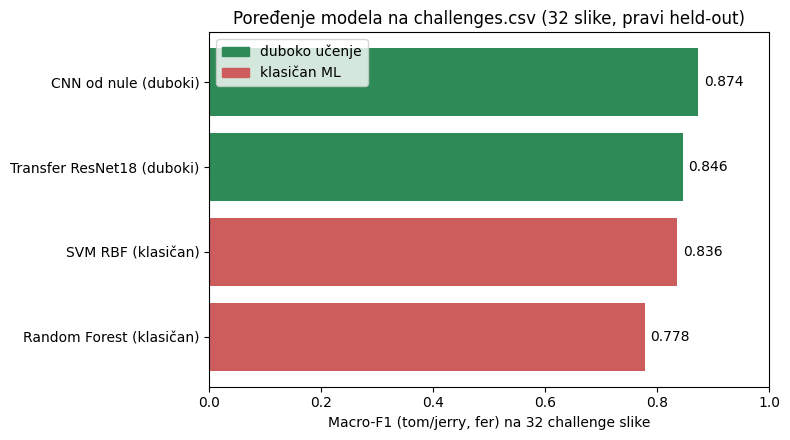

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

t = tabela.sort_values('macro_f1_fer')
boje = ['seagreen' if '(duboki)' in m else 'indianred' for m in t['model']]

plt.figure(figsize=(8, 4.5))
plt.barh(t['model'], t['macro_f1_fer'], color=boje)
for i, f in enumerate(t['macro_f1_fer']):
    plt.text(f + 0.01, i, f'{f:.3f}', va='center')
plt.xlim(0, 1); plt.xlabel('Macro-F1 (tom/jerry, fer) na 32 challenge slike')
plt.title('Poređenje modela na challenges.csv (32 slike, pravi held-out)')
plt.legend(handles=[Patch(color='seagreen', label='duboko učenje'),
                    Patch(color='indianred', label='klasičan ML')])
plt.tight_layout(); plt.show()

### 7. Pregled po pojedinačnim slikama

In [10]:
pregled = challenge_df[['filename', 'class']].copy()
pregled.columns = ['filename', 'stvarno']
pregled['RF'] = pred_rf
pregled['SVM'] = pred_svm
pregled['CNN'] = pred_cnn
pregled['ResNet18'] = pred_res

# koliko od 4 modela je pogodilo svaku sliku
pregled['broj_tacnih'] = pregled.apply(
    lambda r: sum(r[m] == r['stvarno'] for m in ['RF','SVM','CNN','ResNet18']), axis=1
)

pregled = pregled.sort_values('broj_tacnih')
pregled

,filename,stvarno,RF,SVM,CNN,ResNet18,broj_tacnih
1,frame360.jpg,jerry,neither,neither,neither,neither,0
0,frame46.jpg,tom,tom,neither,neither,both,1
2,frame715.jpg,tom,neither,neither,both,tom,1
11,frame2215.jpg,tom,neither,neither,tom,neither,1
31,frame5436.jpg,jerry,tom,jerry,tom,neither,1
7,frame1794.jpg,jerry,tom,both,jerry,jerry,2
27,frame5399.jpg,jerry,neither,neither,jerry,jerry,2
5,frame1686.jpg,tom,tom,both,tom,tom,3
15,frame2942.jpg,jerry,jerry,jerry,jerry,neither,3
8,frame1795.jpg,jerry,neither,jerry,jerry,jerry,3


### 8. Vizuelni prikaz — najteže i najlakše slike

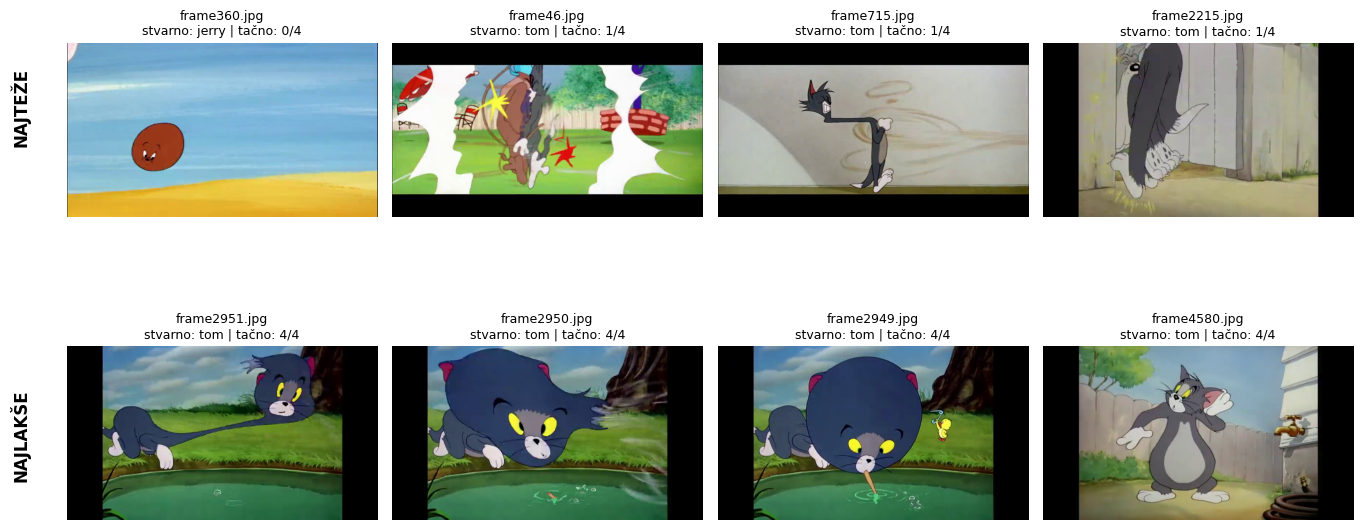

In [11]:
import cv2
import matplotlib.pyplot as plt

prikaz = pregled.merge(challenge_df[['filename', 'filepath']], on='filename')

najteze = prikaz.sort_values('broj_tacnih').head(4)
najlakse = prikaz.sort_values('broj_tacnih', ascending=False).head(4)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, (_, row) in enumerate(najteze.iterrows()):
    img = cv2.cvtColor(cv2.imread(row['filepath']), cv2.COLOR_BGR2RGB)
    axes[0, col].imshow(img)
    axes[0, col].axis('off')
    axes[0, col].set_title(f"{row['filename']}\nstvarno: {row['stvarno']} | tačno: {row['broj_tacnih']}/4", fontsize=9)

for col, (_, row) in enumerate(najlakse.iterrows()):
    img = cv2.cvtColor(cv2.imread(row['filepath']), cv2.COLOR_BGR2RGB)
    axes[1, col].imshow(img)
    axes[1, col].axis('off')
    axes[1, col].set_title(f"{row['filename']}\nstvarno: {row['stvarno']} | tačno: {row['broj_tacnih']}/4", fontsize=9)

fig.text(0.03, 0.75, 'NAJTEŽE', rotation=90, va='center', fontsize=12, fontweight='bold')
fig.text(0.03, 0.28, 'NAJLAKŠE', rotation=90, va='center', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0.06, 0, 1, 1])
plt.show()

## Zaključak — 07

- Svih 32 slike iz `challenges.csv` su **pravi held-out skup** — ni jedan model ih nije video tokom treninga
  (isključene su iz train/val/test u `01_eda_split.ipynb`).
- Poredak po fer macro-F1 (samo tom/jerry, pošto ovih 32 slike ne sadrže "both"/"neither"):
  **CNN od nule (0.874) > Transfer ResNet18 (0.846) > SVM (0.836) > Random Forest (0.778)**.
- Zanimljiv obrt u odnosu na pun test skup: tamo je ResNet18 ubjedljivo najbolji (0.79), a CNN dosta slabiji (0.55).
  Ovde su skoro izjednačeni, uz blagu prednost CNN-a. Napomena: uzorak je mali (32 slike), pa razlike
  između modela treba tumačiti oprezno — mogu dijelom biti statistički šum.
- Kad modeli greše, uglavnom NE miješaju tom↔jerry međusobno — umesto toga predviđaju "both" ili "neither",
  što sugeriše da model "osjeti" da je slika granična/neobična, čak i kad ne pogodi tačnu klasu.
- Jedina slika koju su promašila SVA 4 modela (`frame360.jpg`) vizuelno ne liči na Jerry-ja
  (izgleda kao lopta/kamen na plaži) — konkretan dokaz da je autor dataset-a opravdano označio
  ovih 32 slike kao teške/granične.